In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

In [2]:
bolly_df=pd.read_csv("bollywood.csv")
print(bolly_df)

     SlNo Release Date                    MovieName ReleaseTime      Genre  \
0       1    18-Apr-14                     2 States          LW    Romance   
1       2     4-Jan-13                 Table No. 21           N  Thriller    
2       3    18-Jul-14           Amit Sahni Ki List           N     Comedy   
3       4     4-Jan-13             Rajdhani Express           N     Drama    
4       5     4-Jul-14                 Bobby Jasoos           N     Comedy   
..    ...          ...                          ...         ...        ...   
144   145    27-Feb-15           Dum Laga Ke Haisha           N     Comedy   
145   146    13-Mar-15                         NH10           N   Thriller   
146   147    20-Mar-15  Dilliwali Zaalim Girlfriend           N     Comedy   
147   148    20-Mar-15                     Hunterrr           N     Comedy   
148   149    23-May-14                Kochadaiiyaan          HS     Action   

     Budget  BoxOfficeCollection  YoutubeViews  YoutubeLikes  Y

In [3]:
#no.of recors
x=bolly_df.shape
print(f"no. of records: {x[0]}")

no. of records: 149


In [4]:
#metadata
bolly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SlNo                 149 non-null    int64  
 1   Release Date         149 non-null    object 
 2   MovieName            149 non-null    object 
 3   ReleaseTime          149 non-null    object 
 4   Genre                149 non-null    object 
 5   Budget               149 non-null    int64  
 6   BoxOfficeCollection  149 non-null    float64
 7   YoutubeViews         149 non-null    int64  
 8   YoutubeLikes         149 non-null    int64  
 9   YoutubeDislikes      149 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 11.8+ KB


In [8]:
x=bolly_df.Genre.value_counts()     #by default : descending, else bolly_df.Genre.value_counts(ascending=True) 
print(f"Movies released in each genre:\n{x.reset_index().to_string(index=False)}")

Movies released in each genre:
    Genre  count
   Comedy     36
   Drama      35
 Thriller     26
  Romance     25
   Action     21
Thriller       3
  Action       3


In [11]:
top_genre=bolly_df['Genre'].value_counts().idxmax()
print(f"Genre with highest number of releases: {top_genre}")

Genre with highest number of releases: Comedy


In [13]:
y=pd.crosstab(bolly_df['Genre'], bolly_df['ReleaseTime'])
print(f"Genre vs Release Time\n{y}")

Genre vs Release Time
ReleaseTime  FS  HS  LW   N
Genre                      
 Drama        4   6   1  24
Action        3   3   3  12
Action        0   0   0   3
Comedy        3   5   5  23
Romance       3   3   4  15
Thriller      4   1   1  20
Thriller      0   0   1   2


In [15]:
bolly_df['Release Date'] = pd.to_datetime( bolly_df['Release Date'], format='%d-%b-%y' )
bolly_df['Month']= bolly_df['Release Date'].dt.month_name()
mon_name=bolly_df['Month'].value_counts().idxmax()

print(f"In {mon_name}, maximum number of movie releases are seen.")

In January, maximum number of movie releases are seen.


In [17]:
bolly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   SlNo                 149 non-null    int64         
 1   Release Date         149 non-null    datetime64[ns]
 2   MovieName            149 non-null    object        
 3   ReleaseTime          149 non-null    object        
 4   Genre                149 non-null    object        
 5   Budget               149 non-null    int64         
 6   BoxOfficeCollection  149 non-null    float64       
 7   YoutubeViews         149 non-null    int64         
 8   YoutubeLikes         149 non-null    int64         
 9   YoutubeDislikes      149 non-null    int64         
 10  Month                149 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(4)
memory usage: 12.9+ KB


In [19]:
mon=bolly_df.loc[bolly_df['Budget']>25, 'Month'].value_counts().idxmax()
print(f"In {mon}, there is most releases of high budgeted movies (>25cr).")

In February, there is most releases of high budgeted movies (>25cr).


In [21]:
bolly_df['ROI']=(bolly_df['BoxOfficeCollection']-bolly_df['Budget'])/bolly_df['Budget']
sort=bolly_df[['ROI', 'MovieName']].sort_values('ROI', ascending=False).head(10)
op=sort.reset_index(drop=True).to_string(index=False)
print(op)

     ROI                 MovieName
8.166667                Aashiqui 2
7.647059                        PK
7.514286               Grand Masti
7.500000              The Lunchbox
6.240000                    Fukrey
5.933333                  Mary Kom
5.666667                    Shahid
5.500000 Humpty Sharma Ki Dulhania
4.466667        Bhaag Milkha Bhaag
4.266667           Chennai Express


In [23]:
sort1=bolly_df.groupby('ReleaseTime')['ROI'].mean().sort_values(ascending=False)
op1=sort1.reset_index().to_string(index=False)

print(op1)


ReleaseTime      ROI
         LW 1.127205
         FS 0.973853
         HS 0.850867
          N 0.657722


In [25]:
sort2=bolly_df.groupby('Genre')['ROI'].mean()
sort2

Genre
 Drama       1.357455
Action       0.431054
Action      -0.602028
Comedy       0.788394
Romance      1.003218
Thriller     0.169578
Thriller     0.421667
Name: ROI, dtype: float64

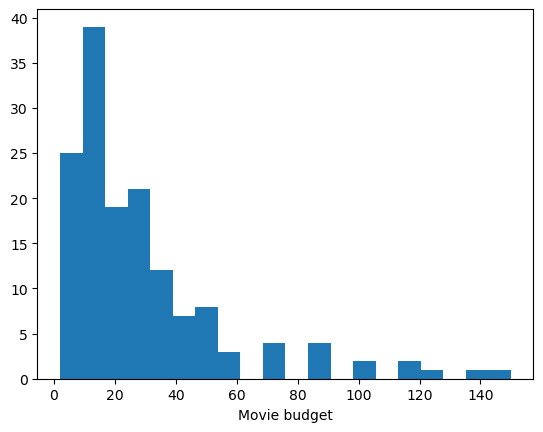

In [27]:
plt.hist(bolly_df['Budget'], bins=20)
plt.xlabel("Movie budget")
plt.show()

C:\Users\STUDENT_NEW\AppData\Local\Temp\ipykernel_6676\67507093.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(bolly_df['Budget'])


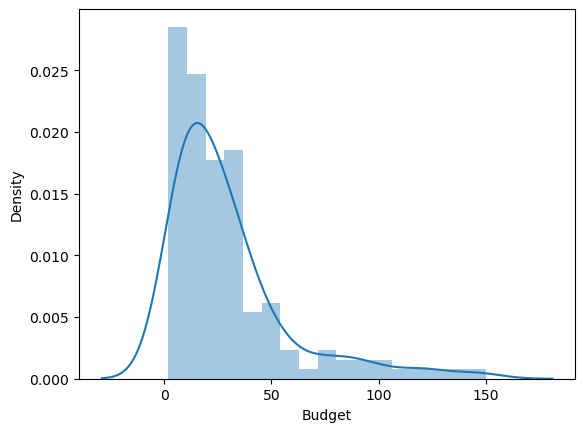

In [29]:
sn.distplot(bolly_df['Budget'])
plt.show()

In [31]:
bolly_df['Genre'].unique()



array(['Romance', 'Thriller ', 'Comedy', ' Drama ', 'Action ', 'Action',
       'Thriller'], dtype=object)

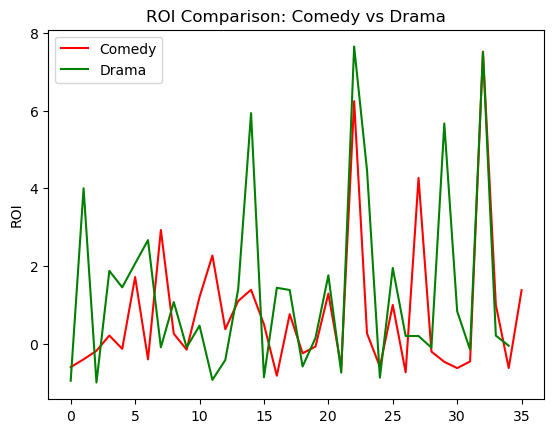

In [33]:
plt.plot(bolly_df[bolly_df['Genre'].str.strip()=='Comedy']['ROI'].reset_index(drop=True), color="red", label="Comedy")
plt.plot(bolly_df[bolly_df['Genre'].str.strip()=='Drama']['ROI'].reset_index(drop=True), color="Green", label="Drama")
plt.ylabel('ROI')
plt.legend()
plt.title('ROI Comparison: Comedy vs Drama')
plt.show()


In [35]:
arg=['BoxOfficeCollection', 'YoutubeLikes']
bolly_df[arg].corr()

,BoxOfficeCollection,YoutubeLikes
BoxOfficeCollection,1.000000,0.682517
YoutubeLikes,0.682517,1.000000


In [37]:
ylikes=bolly_df.groupby('Genre')['YoutubeLikes'].mean().sort_values(ascending=False)
formatt=ylikes.reset_index().to_string(index=False)
print(f"{formatt}")

    Genre  YoutubeLikes
   Action  18340.666667
   Drama    7973.628571
  Romance   7089.640000
  Action    5573.000000
Thriller    5096.000000
 Thriller   4924.000000
   Comedy   4784.722222


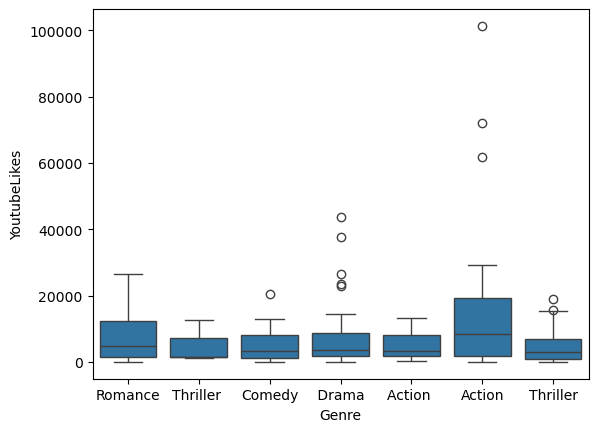

In [39]:
sn.boxplot(x='Genre', y='YoutubeLikes', data=bolly_df)
plt.show()

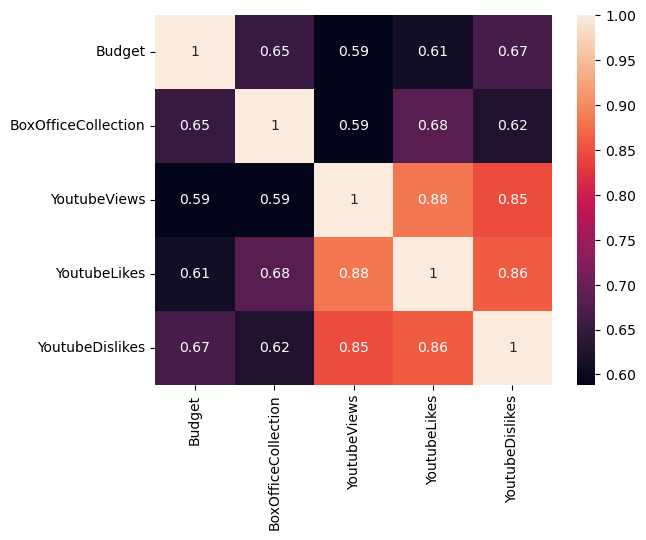

In [41]:
val=['Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']
sn.heatmap(bolly_df[val].corr(), annot=True)
plt.show()